# Self-interaction of an atom near a surface

This notebook calculates the surface-induced self-interaction of a single rubidium Rydberg atom near a perfectly conducting plane.
The self-interaction shifts the atomic energy levels and can also mix nearby Rydberg states when the atom is close to the surface.

In [1]:
# %pip install -q pairinteraction # Uncomment for installation on Colab

import matplotlib.pyplot as plt
import numpy as np
import pairinteraction as pi
from pairinteraction.visualization.colormaps import alphamagma

if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)

The reference state is $69P_{1/2}, m=1/2$ of rubidium.
A single-atom basis is built around this state, and then the atom-surface distance is swept from $1\,\mu\mathrm{m}$ to $8\,\mu\mathrm{m}$.
For each distance, a `GreenTensorSurface` object represents a plane below the atom with its normal along the $z$ axis.
The vacuum contribution has to be omitted, since the resulting free space contribution (Lamb shift) is already included in the atomic energy levels.

In [2]:
ket = pi.KetAtom("Rb", n=69, l=1, j=0.5, m=0.5)
basis = pi.BasisAtom.from_kets(ket, delta_nu=3, delta_l=3)

atom_surface_distances = np.linspace(1, 8, 300)

system_list: list[pi.SystemAtom] = []
for z in atom_surface_distances:
    system = pi.SystemAtom(basis)
    gt = pi.green_tensor.GreenTensorSurface(
        [0, 0, 0],
        [0, 0, 0],
        point_on_plane=[0, 0, -z],
        surface_normal=[0, 0, 1],
        unit="micrometer",
        without_vacuum_contribution=True,
    )
    system.set_green_tensor(gt)
    system_list.append(system)

pi.diagonalize(system_list)

energies_list = [
    system.get_eigenenergies(unit="MHz") - ket.get_energy("MHz") for system in system_list
]
overlaps_list = [system.get_eigenbasis().get_overlaps(ket) for system in system_list]

The plot shows the shifted eigenenergies as gray lines and colors each eigenstate by its overlap with the original $69P_{1/2}, m=1/2$ state.
At large distances, the branch connected to the reference state follows the expected static Casimir-Polder scaling proportional to $1/d^3$, shown by the dashed fit.
At short distances, the colored overlap reveals surface-induced mixing with nearby states.

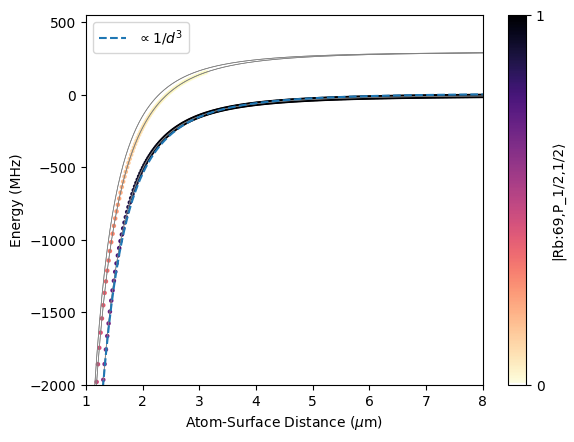

In [3]:
fig, ax = plt.subplots()

ax.plot(atom_surface_distances, energies_list, c="0.5", lw=0.5)

x_repeated = np.hstack(
    [
        val * np.ones_like(es)
        for val, es in zip(atom_surface_distances, energies_list, strict=True)
    ]
)
energies_flattened = np.hstack(energies_list)
overlaps_flattened = np.hstack(overlaps_list)
sorter = np.argsort(overlaps_flattened)
scat = ax.scatter(
    x_repeated[sorter],
    energies_flattened[sorter],
    c=overlaps_flattened[sorter],
    s=5,
    cmap=alphamagma,
    zorder=-20,
)
cbar = fig.colorbar(scat, ax=ax, label=str(ket))
cbar.set_ticks([0, 1])

_id = system_list[-1].get_eigenbasis().get_corresponding_state_index(ket)
energies = np.array(energies_list)[:, _id]
a, b = np.polyfit(1 / atom_surface_distances**3, energies, deg=1)
energies_fitted = a / atom_surface_distances**3 + b
ax.plot(
    atom_surface_distances,
    energies_fitted,
    "C0--",
    label=r"$\propto 1/d^3$",
)

ax.legend()
ax.set_xlabel(r"Atom-Surface Distance ($\mu$m)")
ax.set_ylabel(r"Energy (MHz)")

ax.set_ylim(-2000, 550)
ax.set_xlim(1, 8)


plt.show()